# 4. 구현 : 시뮬레이션과 완전 탐색

# 참고
[(이코테 2021 강의 몰아보기) 2. 그리디 & 구현
](https://www.youtube.com/watch?v=2zjoKjt97vQ&list=PLRx0vPvlEmdAghTr5mXQxGpHjWqSz0dgC&index=2)

## lecture 14. 구현 유형 개요

### 구현(Implementation)

구현이란, 머릿속에 있는 알고리즘을 소스코드로 바꾸는 과정이다.

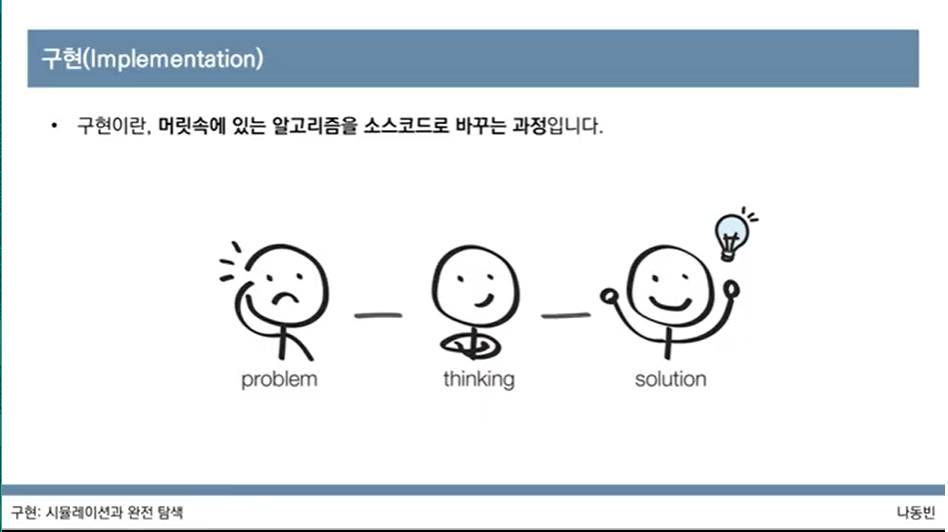

소스 코드가 없이 알고리즘만 있다면 실제로 동작하지 않으므로 구현은 필수이다. 따라서, 모든 알고리즘 문제는 사실상 구현 문제라고 볼 수 있다. 하지만 일반적으로 구현 문제라고 부르는 것은 구현에 초점을 맞추고 있거나 구현이 어려운 문제 유형을 의미한다.

흔히 알고리즘 대회에서 구현 유형의 문제란, 풀이를 떠올리는 것은 쉽지만 소스코드로 옮기기 어려운 문제를 지칭한다.

구현 유형의 예시는 다음과 같다.
1. 알고리즘은 간단한데 코드가 지나칠 만큼 길어지는 문제
* 프로그래밍의 언어에 영향을 받기도 한다.
2. 실수 연산을 다루고, 특정 소수점 자리까지 출력해야 하는 문제
* 문법적으로 특정 프로그래밍 언어로 구현할 수 있어야 하기 때문이다.
3. 문자열을 특정한 기준에 따라서 끊어 처리해야 하는 문제
* 문자열 처리는 파이썬이 편하다. 
4. 적절한 라이브러리를 찾아서 사용해야 하는 문제
* 적절한 라이브러리를 사용해봐야 하기 때문에 경험이 중요하다.

일반적으로 알고리즘 문제에서의 2차원 공간은 행렬(Matrix)의 의미로 사용된다.

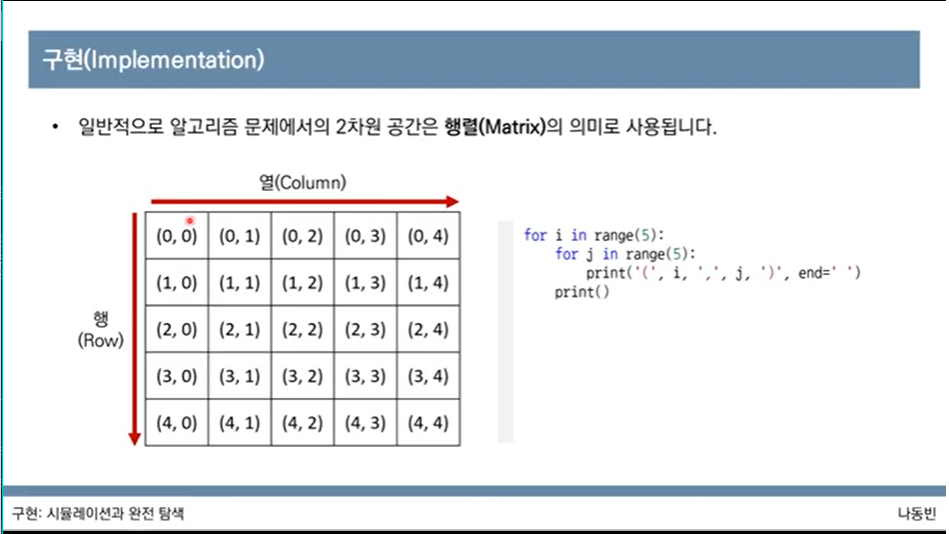

시뮬레이션 및 완전 탐색 문제에서는 2차원 공간에서 방향 벡터가 자주 활용된다.

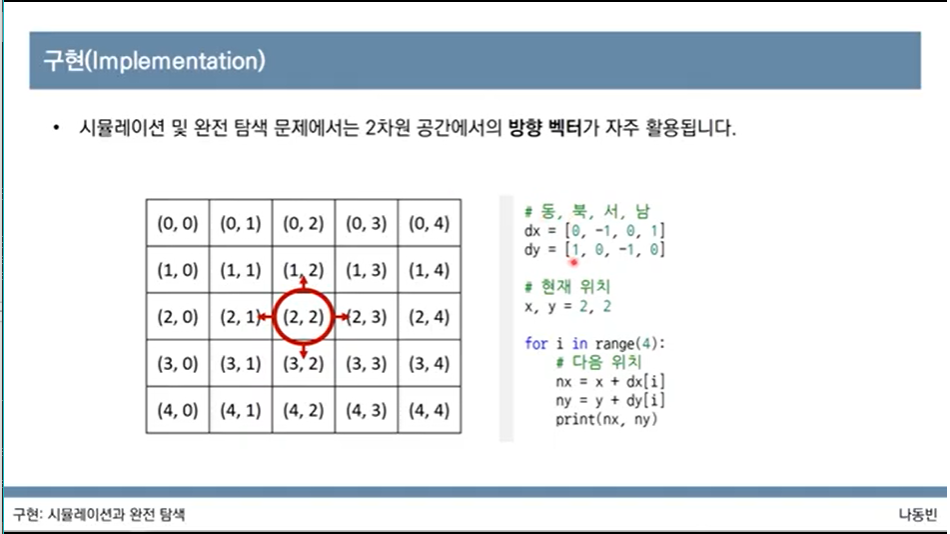

### 문제 

#### 상하좌우 : 문제 설명

여행가 A는 N X N 크기의 정사각형 공간 위에 서 있다. 이 공간은 1 X 1 크기의 정사각형으로 나누어져 있다. 가장 왼쪽 위 좌표는 (1,1)이며, 가장 오른쪽 아래 좌표는 (N,N)에 해당한다. 여행가 A는 상, 하, 좌, 우 방향으로 이동할 수 있으며, 시작 좌표는 항상 (1,1)이다. 우리 앞에는 여행가 A가 이동할 계획이 적인 계획서가 놓여 있다.

계획서에는 하나의 줄에 띄어쓰기를 기준으로 하여 L, R, U, D 중 하나의 문자가 반복적으로 적혀 있습니다. 각 문자의 의미는 다음과 같다.

L : 왼쪽으로 한 칸 이동
R : 오른쪽으로 한 칸 이동
U : 위로 한 칸 이동
D : 아래로 한 칸 이동

이때 여행가 A가 N X N 크기의 정사각형 공간을 벗어나는 움직임은 무시된다. 예를 들멵 (1,1) 위치에서 L 혹은 U를 만나면 무시된다. 다음은 N=5인 지도와 계획서이다.

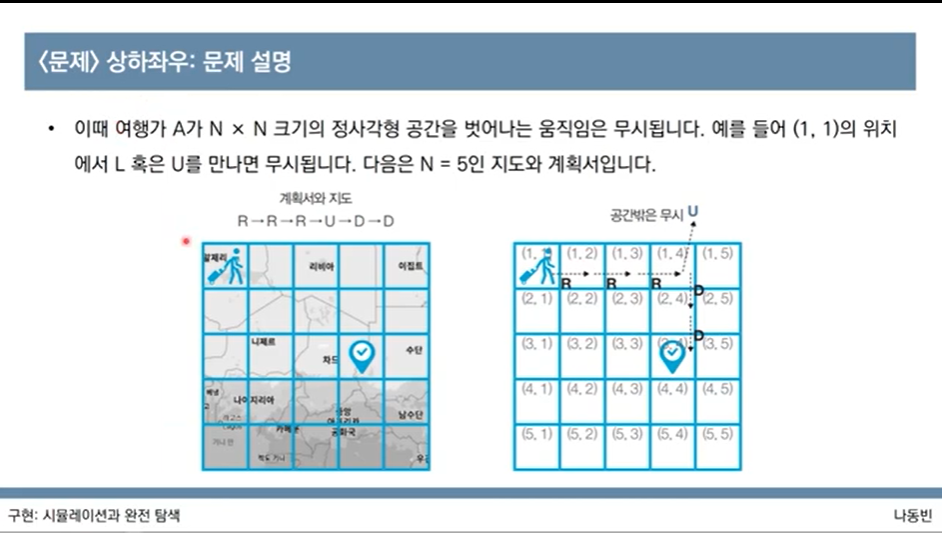

난이도 : 하, 풀이 시간 15분, 시간 제한 2초, 메모리 제한 128MB

입력 조건 : 첫째 줄에 공간의 크기를 나타내는 N이 주어진다.(1 <= N <=100)
둘째 줄에 여행가 A가 이동할 계획서 내용이 주어진다.(1 <= 이동 횟수 <= 100)

출력 조건 : 첫째 줄에 여행가 A가 최종적으로 도착할 지점의 좌표(X,Y)를 공백을 기주능로 구분하여 출력한다.

#### 상하좌우 : 저자 풀이

#####  상하좌우 : 문제 해결 아이디어

이 문제는 요구사항대로 충실히 구현하면 되는 문제이다.

일련의 명령에 따라서 개체를 차례대로 이동시킨다는 점에서 시뮬레이션(Simulation) 유형으로도 분류되며 구현이 중요한 대표적인 문제 유형이다.
* 다만 알고리즘 교재나 문제 풀이 사이트에 따라서 다르게 일컬을 수 있으므로, 코딩 테스트에서의 시뮬레이션 유형, 구현 유형, 완전 탐색 유형은 서로 유사한 점이 많다는 정도로만 기억한다.

##### 상하좌우 : 답안  예시

```python
# N입력 받기
n = int(input())
x, y = 1, 1
plans = input().split()

# L, R, U, D에 따른 이동 방향
dx = [0, 0, -1, 1]
dy = [-1, 1, 0, 0]
move_types = ['L','R', 'U', 'D']

# 이동 계획을 하나씩 확인하기
for plan in plans:
    # 이동 후 좌표 구하기
    for i in range(len(move_types)):
        if plan == move_types[i]:
            nx = x + dx[i]
            ny = y + dy[i]     
            # 파이썬은 nx와 ny를 사용되기 전에 초기화 하지 않아도 바로 값을 대입해서 반복문 바깥에 if문에서 바로 참조할 수 있다.
    # 공간을 벗어나는 경우 무시
    if nx < 1 or ny < 1 or nx > n or ny > n: 
        continue
    # 이동 수행
    x, ny = nx, ny
print(x, y)
```

#### 상하좌우 : 나의 풀이

##### 상하좌우 : 문제 해결 아이디어

L, R, U, D를 수행하되 가장자리에서 제약을 받는 경우는 넘긴다.

##### 상하좌우 : 답안

In [7]:
N = int(input())
plan = input().split()


start = [1,1]

for i in plan:
    if i == 'R' and start[1] < N:
        start[1] += 1
    elif i == 'L' and start[1] > 1:
        start[1] -= 1
    elif i == 'U' and start[0] > 1:
        start[0] -= 1
    elif i == 'D' and start[0] < N:
        start[0] += 1
    else:
        continue
print(start[0], ' ', start[1])
        

5
R R R U D D
3   4


## lecture 15 구현 유형 문제 풀이

### 시각 : 문제 설명

정수 N이 입력되면 00시 00분 00초부터 N시 59분 59초까지의 모든 시각 중에서 3이 하나라도 포함되는 모든 경우의 수를 구하는 프로그램을 작성하시오. 예를 들어 1을 입력했ㅇ르 대 다음은 3이 하나라도 포함되어 있으므로 세어야 하는 시각이다.
00시 00분 03초
00시 13분 30초

반면에 다음은 3이 하나도 포함되어 있지 않으므로 세면 안되는 시각이다.
00시 02분 55초
01시 27분 45초

난이도 : 하, 풀이시간 15분, 시간 제한 2초, 메모리 제한 128MB

입력 조건 : 천째 주에 정수 N이 입력된다. (0 <= N <= 23)
출력 조건 : 00시 00분 00초부터 N시 59분 59초까지의 모든 시각 중에서 3이 하나라도 포함되는 모든 경우의 수를 출력합니다.

12시 35분 시작

#### 나의 풀이

##### 시각 : 문제 해결 아이디어

1. '초'에 3이 들어가는 경우의 수를 센다.
2. '분'에 3이 들어가는 경우와 들어가지 않는 경우의 수를 각각 센다.
3. '시'에 3이 들어가는 경우의 수를 센다.


##### 시각 : 풀이

In [1]:
N = int(input())
result =0

# '시'에 3이 들어가는 경우
hour_3 = N // 3
result = hour_3 * 60 * 60

# '시'에 3이 들어가지 않는 경우
    # '분'에 3이 들어가는 경우 + '분'에 3이 들어가지 않는 경우
minute_3 = 15 * 60 + (60-15) * 15
result = (N - hour_3) * minute_3

print(result)
# 1차 12시 48분

5
6300


In [2]:
N = int(input())
result =0

# '시'에 3이 들어가는 경우
hour_3 = N // 3

# '시'에 3이 들어가지 않는 경우
    # '분'에 3이 들어가는 경우 + '분'에 3이 들어가지 않는 경우
minute_3 = 15 * 60 + (60-15) * 15
result = hour_3 * 60 * 60 + (N - hour_3) * minute_3

print(result)
# 2차 12시 52분

5
9900


In [12]:
N = int(input())
result =0

# '시'에 3이 들어가는 경우
hour_3 = N // 3
result += hour_3 * 60 * 60

# '시'에 3이 들어가지 않는 경우
    # '분'에 3이 들어가는 경우
minute_3 = 15
result += (N - hour_3) * minute_3 * 60

    # '분'에 3이 들어가지 않는 경우
        # '초'에 3이 들어가는 경우
second_3 = 15
result += (N - hour_3 ) * (60 - minute_3) * second_3

print(result)
# 3차 1시 05분

5
11475


In [9]:
N = int(input())
result =0

# '시'에 3이 들어가는 경우
hour_3 = N // 3
result += hour_3 * 60 * 60

# '시'에 3이 들어가지 않는 경우
    # '분'에 3이 들어가는 경우
minute_3 = 15
result += (N - hour_3 + 1) * minute_3 * 60

    # '분'에 3이 들어가지 않는 경우
        # '초'에 3이 들어가는 경우
second_3 = 15
result += (N - hour_3 + 1) * (60 - minute_3) * second_3

print(result)
# 4차 1시 23분
저자 풀이 보다가 h+1보고 떠오름
예외의 경우 생각해보기
즉, 실제 수 대입해서 놓치는 건 없는지 확인하기

9900

#### 저자 풀이

##### 시각 : 문제 해결 아이디어

이 문제는 가능한 모든 시각의 경우를 하나씩 모두 세서 풀 수 있는 문제이다.

하루는 86,400초이므로, 00시 00분 00초부터 23시 59분 59초까지의 모든 경우는 86,400가지이다.
* 24 * 60 * 60 = 86,400

따라서 단순히 시각을 1씩 증가시키면서 3이 하나라도 포함되어 있는지 확인하면 된다.
이런한 유형은 완전 탐색(Brute Forcing)문제 유형이라고 불린다.
* 가능한 경우의 수를 모두 검사해보는 탐색 방법을 의미한다.

##### 시각 : 답안 예시
```python
# H 입력 받기
h = int(input())

count = 0
for i in range(h+1): # 0부터 h까지 1씩 증가
    for j in range(60): # j는 분
        for k in range(60): # k는 초
            # 매 시각 안에 '3'이 포함되어 있다면 카운트 증가
            if '3' in str(i) + str(j) + str(k):
                count += 1
                
print(count)
```

### 왕실의 나이트 : 문제 설명
4:04
행복 왕

4: 06

#### 나의 풀이

##### 문제 해결 아이디어

1. 열과 행을 숫자로 표현
2. 말이 움직일 수 있는 거리를 표현
3. 연산으로 경우 나누기


In [16]:
place = input()
x, y = place[0], int(place[1])
column = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

n=1
for i in column:
    if i == x:
        x_num=n
        break
    else:
        n += 1

dx = [-2, -2, 2, 2, -1, -1, 1, 1]
dy = [-1, 1, -1, 1, -2, 2, -2, 2]

count = 0
for i in range(8):
    nx = x_num + dx[i]
    ny = y + dy[i]
    if 0 < nx < 9 and 0 < ny < 9:
        count += 1
print(count)

# 1차 4시 21분

a1
2


#### 저자 풀이

##### 왕실의 나이트 : 문제 해결 아이디어

요구사항대로 충실히 구현하면 되는 문제이다.

나이트의 8가지 경로를 하나씩 확인하며 각 위치로 이동이 가능한지 확인하다.
리스트를 이용하여 8가지 방향에 대한 방향 벡터를 정의한다.

##### 왕실의 나이트 : 답안 예시

```python
# 현재 나이트의 위치 입력받기
input_data = input()
row = int(input_data[1])
column = int(ord(input_data[0])) - int(ord('a')) + 1 # 아스키코드 이용

# 나이트가 이동할 수 있는 8가지 방향 정의
steps = [(-2, -1), (-1, -2), (1, -2), (2, -1), (2, 1), (1, 2), (-1, 2), (-2,1)]

# 8가지 방향에 대하여 각 위치로 이동이 가능한지 확인
result = 0
for step in steps:
    # 이동하고자 하는 위치 확인
    next_row = row + step[0]
    next_column = column + step[1]
    # 해당 위치로 이동이 가능하다면 카운트 증가
    if next_row >= 1 and next_row <= 8 and next_column >= 1 and next_column <= 8:
        result += 1
        
print(result)
```

왕실의 나이트는 전형적인 2차원 공간이 등장하는 문제로 2차원 리스트 혹은 2차원 배열이 사용되는 전형적인 구현 문제이다.

### 문자열 재정렬 : 문제 설명



8: 16

In [35]:
S = list(input())

S_num = [x for x in S if x == '0' or x == '1' or x=='2' or x=='3' or x=='4' or x=='5' or x=='6' or x=='7' or x=='8' or x=='9']
S_string = [x for x in S if x != '0' and x != '1' and x !='2' and x!='3' and x!='4' and x!='5' and x!='6' and x!='7' and x!='8' and x!='9']

number = 0
for x in S_num: 
    number += int(x)

S_string = [ord(x) for x in S_string]
S_string.sort()
S_string = [chr(x) for x in S_string]

result = "".join(S_string) + str(number)
print(result)
#8 : 33 - 42분 끝

123KADF
ADFK6


In [33]:
S = list(input())

S_num = [x for x in S if x == 0 or x == 1 or x==2 or x==3 or x==4 or x==5 or x==6 or x==7 or x==8 or x==9]
S_string = [x for x in S if x != 0 and x != 1 and x !=2 and x!=3 and x!=4 and x!=5 and x!=6 and x!=7 and x!=8 and x!=9]
print(S_num, S_string)

123
[] ['1', '2', '3']


#### 저자의 풀이

##### 문자열 재정렬 : 문제 해결 아이디어

요구사항대로 충실히 구현하면 되는 문제이다.

문자열이 입력되었을 때 문자를 하나씩 확인합니다.
숫자인 경우 따로 합계를 계산한다.
알파벳인 경우 별도의 리스트에 저장한다.

결과적으로 리스트에 저장된 알파벳을 정렬해 출력하고, 합계를 뒤에 붙여 출력하면 정답이다.

##### 문자열 재정렬 : 답안 제시

```python
data = input()
result = []
value = 0

# 문자를 하나씩 확인하며
for x in data:
    # 알파벳인 경우 결과 리스트에 삽입
    if x.isalpha():
        result.append(x)
    # 숫자는 따로 더하기
    else:
        value += int(x)
        
# 앞파벳을 오름차순으로 정렬
result.sort()

# 숫자가 하나라도 존재하는 경우 가장 뒤에 삽입
if value != 0:
    result.append(str(value))
    
# 최종 결과 출력(리스트를 문자열로 변환하여 출력)
print("".join(result))
```